# Module 03: Feature Engineering — Encoding Numerical Features (Discretization & Binarization)

In this notebook, we explore the practical implementation of **Discretization (Binning)** and **Binarization** in Python using Scikit-Learn.

### Learning Goals:
1. Understand why and when to convert continuous numerical features into discrete groups.
2. Master all three strategies of `KBinsDiscretizer`: **Equal Width (`uniform`)**, **Equal Frequency (`quantile`)**, and **K-Means (`kmeans`)**.
3. Understand the `n_bins` and `encode` parameters (`ordinal` vs `onehot-dense`).
4. Master `Binarizer` and understand its exact inequality behavior ($x > \text{threshold} \implies 1$).
5. Visualize bin boundaries directly on feature distributions.
6. Prevent train/test data leakage with strict split-first protocols.
7. Integrate discretizers into `ColumnTransformer` and end-to-end `Pipeline` workflows.
8. Evaluate a real model experiment comparing continuous scaling vs. quantile binning on Titanic passenger survival.

## 1. Imports & Environment Setup
We import standard data science libraries (`numpy`, `pandas`, `matplotlib`, `seaborn`) and Scikit-Learn preprocessing transformers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress harmless warnings for clean notebook presentation
warnings.filterwarnings('ignore')

# Scikit-Learn transformers and models
from sklearn.preprocessing import KBinsDiscretizer, Binarizer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Numerical → Discrete Representation

Consider customer ages:
Instead of treating each continuous number as an isolated value, we often group them into cohorts like Young, Adult, Middle-Aged, and Senior.

In [2]:
# Sample raw continuous ages
raw_ages = np.array([18, 21, 25, 32, 41, 56, 72])

# Conceptual cohort mapping
def map_age_cohort(age):
    if age <= 25:
        return 'Young (18-25)'
    elif age <= 40:
        return 'Adult (26-40)'
    elif age <= 60:
        return 'Middle-Aged (41-60)'
    else:
        return 'Senior (61+)'

cohorts = [map_age_cohort(a) for a in raw_ages]

df_intro = pd.DataFrame({
    'Raw Continuous Age': raw_ages,
    'Discrete Cohort': cohorts
})

print("--- Continuous to Discrete Representation ---")
display(df_intro)

--- Continuous to Discrete Representation ---


,Raw Continuous Age,Discrete Cohort
0,18,Young (18-25)
1,21,Young (18-25)
2,25,Young (18-25)
3,32,Adult (26-40)
4,41,Middle-Aged (41-60)
5,56,Middle-Aged (41-60)
6,72,Senior (61+)


## 3. Understanding Binning
**Binning** partitions the continuous range into distinct intervals $[b_k, b_{k+1})$.
Any observation falling between those boundaries receives that bin's discrete label.

In [3]:
# Noisy sensor readings
noisy_data = pd.Series([23.4, 24.1, 25.7, 26.2, 34.5, 36.8, 52.1, 71.8])

# Bin into decade intervals: [20, 30), [30, 40), [50, 60), [70, 80)
binned_series = pd.cut(noisy_data, bins=[20, 30, 40, 50, 60, 70, 80], right=False)

df_binning_concept = pd.DataFrame({
    'Original Measurement': noisy_data,
    'Simplified Bin Interval': binned_series
})

display(df_binning_concept)

,Original Measurement,Simplified Bin Interval
0,23.4,"[20, 30)"
1,24.1,"[20, 30)"
2,25.7,"[20, 30)"
3,26.2,"[20, 30)"
4,34.5,"[30, 40)"
5,36.8,"[30, 40)"
6,52.1,"[50, 60)"
7,71.8,"[70, 80)"


## 4. Equal Width Binning (`uniform`)
### Manual Calculation & Python Verification
In Equal Width Binning, every interval covers the **exact same numerical span**:
$$\text{Bin Width} = \frac{x_{\max} - x_{\min}}{k}$$

For ages $[10, 15, 20, 25, 30, 35, 40, 45, 50]$ with $k = 4$ bins:
- $\text{Min} = 10, \quad \text{Max} = 50$
- $\text{Range} = 50 - 10 = 40$
- $\text{Bin Width} = 40 / 4 = 10$
- Bin 0: $[10, 20)$, Bin 1: $[20, 30)$, Bin 2: $[30, 40)$, Bin 3: $[40, 50]$

In [4]:
sample_ages = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50]).reshape(-1, 1)

# Fit Equal Width Discretizer (strategy='uniform')
kbd_uniform = KBinsDiscretizer(n_bins=4, strategy='uniform', encode='ordinal')
uniform_bins = kbd_uniform.fit_transform(sample_ages)

df_uniform_manual = pd.DataFrame({
    'Age Value': sample_ages.flatten(),
    'Assigned Bin Index': uniform_bins.flatten().astype(int)
})

print("Learned Bin Edges:", kbd_uniform.bin_edges_[0])
print("\n--- Manual Equal Width Verification ---")
display(df_uniform_manual)

Learned Bin Edges: [10. 20. 30. 40. 50.]

--- Manual Equal Width Verification ---


,Age Value,Assigned Bin Index
0,10,0
1,15,0
2,20,1
3,25,1
4,30,2
5,35,2
6,40,3
7,45,3
8,50,3


## 5. Equal Frequency / Quantile Binning (`quantile`)
### Manual Calculation & Intuition on Skewed Data
Equal Frequency binning ensures that **each bin contains an approximately equal number of observations**, regardless of their numerical spread.

In [5]:
# Skewed dataset with a massive right-tail jump
skewed_data = np.array([1, 2, 2, 3, 3, 4, 5, 6, 50, 100]).reshape(-1, 1)

# Fit Equal Frequency Discretizer (strategy='quantile')
kbd_quantile = KBinsDiscretizer(n_bins=2, strategy='quantile', encode='ordinal')
quantile_bins = kbd_quantile.fit_transform(skewed_data)

print("Learned Quantile Bin Edges (Median Split):", kbd_quantile.bin_edges_[0])

df_quantile_check = pd.DataFrame({
    'Skewed Value': skewed_data.flatten(),
    'Quantile Bin (k=2)': quantile_bins.flatten().astype(int)
})

print("\nValue counts per bin:")
print(df_quantile_check['Quantile Bin (k=2)'].value_counts().sort_index())
display(df_quantile_check)

Learned Quantile Bin Edges (Median Split): [  1.    3.5 100. ]

Value counts per bin:
Quantile Bin (k=2)
0    5
1    5
Name: count, dtype: int64


,Skewed Value,Quantile Bin (k=2)
0,1,0
1,2,0
2,2,0
3,3,0
4,3,0
5,4,1
6,5,1
7,6,1
8,50,1
9,100,1


## 6. Equal Width vs. Equal Frequency Comparison
We directly compare how `uniform` and `quantile` partition the skewed dataset $[1, 2, 2, 3, 3, 4, 5, 6, 50, 100]$ with $k = 2$ bins.

In [6]:
kbd_width = KBinsDiscretizer(n_bins=2, strategy='uniform', encode='ordinal')
width_bins = kbd_width.fit_transform(skewed_data)

comparison_skewed = pd.DataFrame({
    'Original Value': skewed_data.flatten(),
    'Equal Width Bin': width_bins.flatten().astype(int),
    'Equal Frequency Bin': quantile_bins.flatten().astype(int)
})

print("--- Side-by-Side Bin Assignment ---")
display(comparison_skewed)

print("\nObservation Distribution:")
print("Equal Width counts:\n", comparison_skewed['Equal Width Bin'].value_counts().sort_index())
print("\nEqual Frequency counts:\n", comparison_skewed['Equal Frequency Bin'].value_counts().sort_index())

--- Side-by-Side Bin Assignment ---


,Original Value,Equal Width Bin,Equal Frequency Bin
0,1,0,0
1,2,0,0
2,2,0,0
3,3,0,0
4,3,0,0
5,4,0,1
6,5,0,1
7,6,0,1
8,50,0,1
9,100,1,1



Observation Distribution:
Equal Width counts:
 Equal Width Bin
0    9
1    1
Name: count, dtype: int64

Equal Frequency counts:
 Equal Frequency Bin
0    5
1    5
Name: count, dtype: int64


### Interpretation
- **Equal Width:** Puts 9 out of 10 observations into Bin 0, leaving Bin 1 with only 1 observation ($100$). The groups are severely unbalanced.
- **Equal Frequency:** Splits the 10 observations evenly (5 in Bin 0, 5 in Bin 1), adapting smoothly to the skewed distribution.

## 7. K-Means Binning (`kmeans`)
When data naturally clumps into clusters with large empty spaces in between, K-Means binning uses 1D clustering to place boundaries at the midpoints between cluster centroids.

In [7]:
# Clustered dataset
clustered_data = np.array([
    10, 12, 14, 15,          # Cluster 1: Micro
    50, 52, 55, 57,          # Cluster 2: Standard
    100, 105, 110, 115       # Cluster 3: Enterprise
]).reshape(-1, 1)

# Fit K-Means Discretizer
kbd_kmeans = KBinsDiscretizer(n_bins=3, strategy='kmeans', encode='ordinal', random_state=42)
kmeans_bins = kbd_kmeans.fit_transform(clustered_data)

print("K-Means Discovered Bin Edges:")
print(np.round(kbd_kmeans.bin_edges_[0], 2))

df_kmeans = pd.DataFrame({
    'Transaction Amount': clustered_data.flatten(),
    'K-Means Bin': kmeans_bins.flatten().astype(int)
})

display(df_kmeans)

K-Means Discovered Bin Edges:
[ 10.    33.12  80.5  115.  ]


,Transaction Amount,K-Means Bin
0,10,0
1,12,0
2,14,0
3,15,0
4,50,1
5,52,1
6,55,1
7,57,1
8,100,2
9,105,2


## 8. Custom / Domain-Based Binning
Sometimes boundaries come from business policies, legal statutes, or clinical guidelines rather than statistical algorithms.
We demonstrate this using `pd.cut()` on Titanic passenger ages.

In [8]:
df_titanic = pd.read_csv('data/titanic.csv')
sample_titanic_ages = df_titanic['Age'].dropna().head(10)

# Domain boundaries: Child (<12), Adolescent (12-18), Adult (18-50), Senior (50+)
custom_bins = [0, 12, 18, 50, 100]
custom_labels = ['Child (0-12)', 'Adolescent (12-18)', 'Adult (18-50)', 'Senior (50+)']

binned_ages = pd.cut(sample_titanic_ages, bins=custom_bins, labels=custom_labels, right=False)

df_domain = pd.DataFrame({
    'Passenger Age': sample_titanic_ages.values,
    'Domain Category': binned_ages.values
})

print("--- Custom / Domain-Based Binning ---")
display(df_domain)

--- Custom / Domain-Based Binning ---


,Passenger Age,Domain Category
0,22.0,Adult (18-50)
1,38.0,Adult (18-50)
2,26.0,Adult (18-50)
3,35.0,Adult (18-50)
4,35.0,Adult (18-50)
5,54.0,Senior (50+)
6,2.0,Child (0-12)
7,27.0,Adult (18-50)
8,14.0,Adolescent (12-18)
9,4.0,Child (0-12)


## 9. Scikit-Learn `KBinsDiscretizer` Deep Dive
### Parameters: `n_bins`, `strategy`, and `encode`

- `n_bins`: The number of discrete bins to create.
- `strategy`: How bin boundaries are positioned (`'uniform'`, `'quantile'`, `'kmeans'`).
- `encode`: How discrete bins are formatted in output:
  - `'ordinal'`: Single integer column ($0, 1, 2, \dots$).
  - `'onehot-dense'`: Dense 2D array of binary indicator columns.

In [9]:
test_feature = np.array([[15], [25], [35], [45]])

# 1. Ordinal Encoding
kbd_ord = KBinsDiscretizer(n_bins=4, strategy='uniform', encode='ordinal')
res_ord = kbd_ord.fit_transform(test_feature)

# 2. One-Hot Dense Encoding
kbd_ohe = KBinsDiscretizer(n_bins=4, strategy='uniform', encode='onehot-dense')
res_ohe = kbd_ohe.fit_transform(test_feature)

print("Original Values:\n", test_feature.flatten())
print("\nOrdinal Encoded (Shape:", res_ord.shape, "):\n", res_ord)
print("\nOne-Hot Dense Encoded (Shape:", res_ohe.shape, "):\n", res_ohe)

Original Values:
 [15 25 35 45]

Ordinal Encoded (Shape: (4, 1) ):
 [[0.]
 [1.]
 [2.]
 [3.]]

One-Hot Dense Encoded (Shape: (4, 4) ):
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


## 10. Head-to-Head Strategy Comparison: `uniform` vs. `quantile` vs. `kmeans`
We generate a multimodal continuous dataset with 120 samples and compare the resulting bin edges and assignments across all three strategies with $k = 4$ bins.

In [10]:
np.random.seed(42)
# Create a realistic bimodal distribution with a right tail
part1 = np.random.normal(loc=20, scale=3, size=50)
part2 = np.random.normal(loc=40, scale=4, size=50)
part3 = np.random.exponential(scale=15, size=20) + 50
synth_feature = np.concatenate([part1, part2, part3]).reshape(-1, 1)

# Fit all three strategies
k_bins = 4
kbd_u = KBinsDiscretizer(n_bins=k_bins, strategy='uniform', encode='ordinal')
kbd_q = KBinsDiscretizer(n_bins=k_bins, strategy='quantile', encode='ordinal')
kbd_k = KBinsDiscretizer(n_bins=k_bins, strategy='kmeans', encode='ordinal', random_state=42)

u_res = kbd_u.fit_transform(synth_feature)
q_res = kbd_q.fit_transform(synth_feature)
k_res = kbd_k.fit_transform(synth_feature)

# Print bin edges
print("--- Learned Bin Boundaries (Edges) ---")
print("Uniform (Equal Width):", np.round(kbd_u.bin_edges_[0], 2))
print("Quantile (Equal Freq):", np.round(kbd_q.bin_edges_[0], 2))
print("K-Means (Clustered):  ", np.round(kbd_k.bin_edges_[0], 2))

--- Learned Bin Boundaries (Edges) ---
Uniform (Equal Width): [ 14.12  36.47  58.82  81.17 103.52]
Quantile (Equal Freq): [ 14.12  20.14  37.65  43.38 103.52]
K-Means (Clustered):   [ 14.12  29.9   48.6   77.74 103.52]


## 11. Visualizing Bin Boundaries on Distributions
We plot the distribution histogram along with vertical dashed lines representing the exact cut points calculated by each strategy.

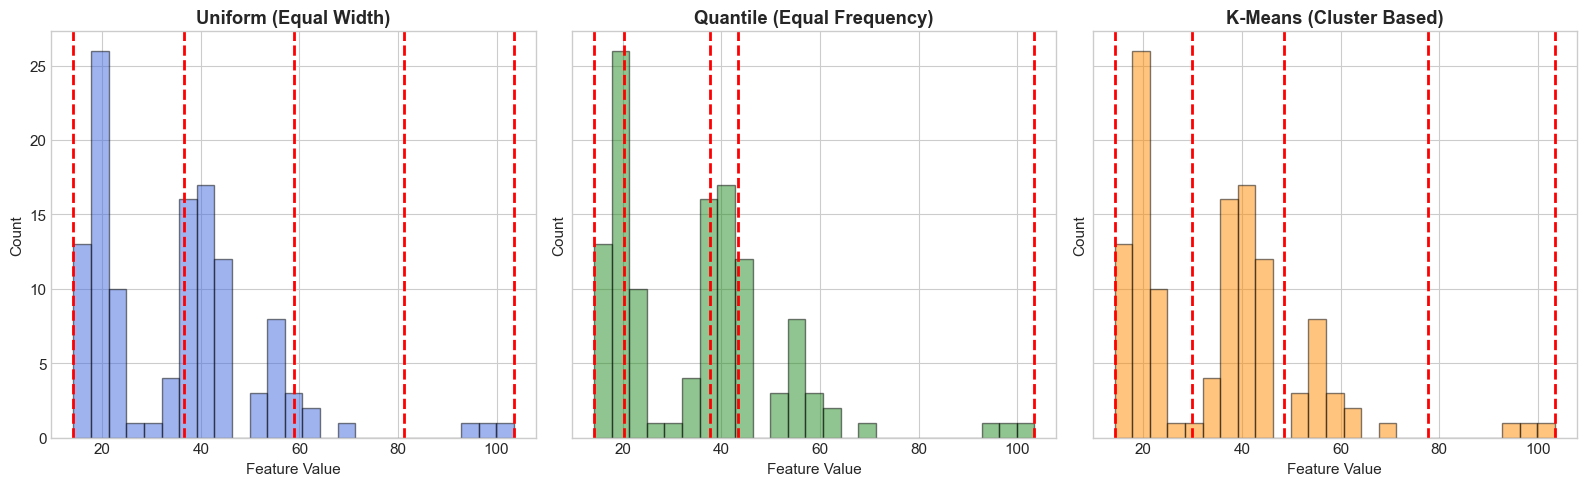

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

strategies = [
    ('Uniform (Equal Width)', kbd_u.bin_edges_[0], 'royalblue', axes[0]),
    ('Quantile (Equal Frequency)', kbd_q.bin_edges_[0], 'forestgreen', axes[1]),
    ('K-Means (Cluster Based)', kbd_k.bin_edges_[0], 'darkorange', axes[2])
]

for title, edges, color, ax in strategies:
    ax.hist(synth_feature, bins=25, color=color, alpha=0.5, edgecolor='black')
    for edge in edges:
        ax.axvline(edge, color='red', linestyle='--', linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Feature Value")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### Visual Takeaways:
- **Uniform:** Red boundary lines are spaced at identical intervals across the entire range.
- **Quantile:** Red boundary lines are packed densely where data points cluster, and spaced far apart in the sparse tail.
- **K-Means:** Red boundary lines naturally settle into the low-density valleys between peaks.

## 12. Binarization: Intuition & Manual Example
Binarization converts continuous numbers into exactly **two binary outcomes** ($0$ or $1$) using a decision threshold.
Example: Is passenger age $\ge 18$?

In [12]:
ages_list = [15, 17, 18, 25, 40]
# Manual evaluation: Age >= 18 -> 1, Age < 18 -> 0
manual_binary = [1 if a >= 18 else 0 for a in ages_list]

df_binarize_manual = pd.DataFrame({
    'Age': ages_list,
    'Condition (Age >= 18)': [f"{a} >= 18" for a in ages_list],
    'Binary Output': manual_binary
})

print("--- Manual Binarization Example ---")
display(df_binarize_manual)

--- Manual Binarization Example ---


,Age,Condition (Age >= 18),Binary Output
0,15,15 >= 18,0
1,17,17 >= 18,0
2,18,18 >= 18,1
3,25,25 >= 18,1
4,40,40 >= 18,1


## 13. Scikit-Learn `Binarizer`
### Critical Implementation Rule on Threshold Inequality:
Scikit-Learn's `Binarizer` strictly implements:
$$\text{Output} = \begin{cases} 1 & \text{if } x > \text{threshold} \\ 0 & \text{if } x \le \text{threshold} \end{cases}$$

Notice: **Values equal to the threshold are mapped to 0!**

In [13]:
X_sample = np.array([[15], [17], [18], [25], [40]])

# Setting threshold=18.0
binarizer_18 = Binarizer(threshold=18.0)
out_18 = binarizer_18.fit_transform(X_sample)

# Setting threshold=17.5 to include integer 18 in the '1' class
binarizer_17_5 = Binarizer(threshold=17.5)
out_17_5 = binarizer_17_5.fit_transform(X_sample)

df_binarizer_comparison = pd.DataFrame({
    'Input Value': X_sample.flatten(),
    'Binarizer(threshold=18.0) [x > 18]': out_18.flatten().astype(int),
    'Binarizer(threshold=17.5) [x >= 18 for ints]': out_17_5.flatten().astype(int)
})

print("--- Binarizer Threshold Precision Check ---")
display(df_binarizer_comparison)

--- Binarizer Threshold Precision Check ---


,Input Value,Binarizer(threshold=18.0) [x > 18],Binarizer(threshold=17.5) [x >= 18 for ints]
0,15,0,0
1,17,0,0
2,18,0,1
3,25,1,1
4,40,1,1


> **Key Insight:**  
> If your business rule is `Age >= 18`, setting `threshold=18.0` incorrectly labels an 18-year-old as `0`. Setting `threshold=17.5` correctly maps `18` to `1`.

## 14. Binning vs. Binarization Comparison
We compare the outputs of `KBinsDiscretizer` (multiple groups) and `Binarizer` (two groups) on the same feature.

In [14]:
comparison_feature = np.array([[12], [17], [22], [35], [52], [68]])

kbd_comp = KBinsDiscretizer(n_bins=3, strategy='uniform', encode='ordinal')
bin_comp = Binarizer(threshold=30.0)

binned_vals = kbd_comp.fit_transform(comparison_feature).flatten().astype(int)
binarized_vals = bin_comp.fit_transform(comparison_feature).flatten().astype(int)

df_bb_comp = pd.DataFrame({
    'Original Value': comparison_feature.flatten(),
    'Binning (KBinsDiscretizer, k=3)': binned_vals,
    'Binarization (Binarizer, threshold=30)': binarized_vals
})

display(df_bb_comp)

,Original Value,"Binning (KBinsDiscretizer, k=3)","Binarization (Binarizer, threshold=30)"
0,12,0,0
1,17,0,0
2,22,0,0
3,35,1,1
4,52,2,1
5,68,2,1


## 15. The Information Loss Trade-Off
Binning simplifies data, but discards fine differences between observations.

In [15]:
fine_data = np.array([[28.1], [28.9], [29.4], [29.9], [31.2]])

kbd_loss = KBinsDiscretizer(n_bins=2, strategy='uniform', encode='ordinal')
loss_output = kbd_loss.fit_transform(fine_data)

df_loss = pd.DataFrame({
    'Continuous Value': fine_data.flatten(),
    'Assigned Bin': loss_output.flatten().astype(int)
})

print("Bin Boundaries:", kbd_loss.bin_edges_[0])
print("\nNotice that 28.1, 28.9, 29.4, and 29.9 are all collapsed to Bin 0:")
display(df_loss)

Bin Boundaries: [28.1  29.65 31.2 ]

Notice that 28.1, 28.9, 29.4, and 29.9 are all collapsed to Bin 0:


,Continuous Value,Assigned Bin
0,28.1,0
1,28.9,0
2,29.4,0
3,29.9,1
4,31.2,1


## 16. Binning and Outlier Handling
Binning does not delete outliers; it bounds their representation into the outermost bin.

In [16]:
data_with_outlier = np.array([[20], [25], [30], [35], [40], [1000]])

# 4 Quantile Bins
kbd_outlier = KBinsDiscretizer(n_bins=4, strategy='quantile', encode='ordinal')
binned_outlier = kbd_outlier.fit_transform(data_with_outlier)

df_outlier = pd.DataFrame({
    'Salary (₹k)': data_with_outlier.flatten(),
    'Assigned Bin': binned_outlier.flatten().astype(int)
})

print("Learned Quantile Edges:", kbd_outlier.bin_edges_[0])
display(df_outlier)

Learned Quantile Edges: [  20.     26.25   32.5    38.75 1000.  ]


,Salary (₹k),Assigned Bin
0,20,0
1,25,0
2,30,1
3,35,2
4,40,3
5,1000,3


Notice that ₹1,000k received `Bin 3`. Its massive magnitude cannot distort distances or gradient calculations anymore.

## 17. Leakage-Proof Train / Test Workflow
Always split data **before** fitting discretizers!

In [17]:
X_dummy = np.array([[10], [15], [20], [25], [30], [35], [40], [45], [50], [100]])
y_dummy = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# 1. Split FIRST
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dummy, y_dummy, test_size=0.3, random_state=42
)

# 2. Fit on TRAIN ONLY
kbd_workflow = KBinsDiscretizer(n_bins=3, strategy='quantile', encode='ordinal')
kbd_workflow.fit(X_train_d)

# 3. Transform both train and test using TRAIN edges
X_train_binned_d = kbd_workflow.transform(X_train_d)
X_test_binned_d = kbd_workflow.transform(X_test_d)

print("Training Bin Edges:\n", kbd_workflow.bin_edges_[0])
print("\nTransformed Test Set (using train boundaries):\n", X_test_binned_d.flatten().astype(int))

Training Bin Edges:
 [ 10.  25.  40. 100.]

Transformed Test Set (using train boundaries):
 [2 0 1]


## 18. Integrating `KBinsDiscretizer` into a `Pipeline`
Pipelines automate the split-first rule seamlessly.

In [18]:
pipeline_bin = Pipeline([
    ('discretizer', KBinsDiscretizer(n_bins=4, strategy='quantile', encode='ordinal')),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Fit on training data
pipeline_bin.fit(X_train_d, y_train_d)

# Predict on test data
test_preds = pipeline_bin.predict(X_test_d)
print("Pipeline predictions on test data:", test_preds)

Pipeline predictions on test data: [1 0 1]


## 19. Multi-Type Preprocessing with `ColumnTransformer`
We discretize `Age`, standardize `Fare`, and one-hot encode `Sex` and `Pclass` from the Titanic dataset.

In [19]:
# Load clean subset of Titanic dataset
titanic_clean = df_titanic[['Survived', 'Age', 'Fare', 'Pclass', 'Sex']].dropna()
X_titanic = titanic_clean[['Age', 'Fare', 'Pclass', 'Sex']]
y_titanic = titanic_clean['Survived']

preprocessor_ct = ColumnTransformer(
    transformers=[
        ('age_bins', KBinsDiscretizer(n_bins=5, strategy='quantile', encode='onehot-dense'), ['Age']),
        ('fare_scale', StandardScaler(), ['Fare']),
        ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), ['Sex', 'Pclass'])
    ],
    remainder='drop'
)

# Fit and transform
X_titanic_prep = preprocessor_ct.fit_transform(X_titanic)
feature_names = preprocessor_ct.get_feature_names_out()

df_prep_sample = pd.DataFrame(np.round(X_titanic_prep[:5], 3), columns=feature_names)
print("--- ColumnTransformer Preprocessed Matrix ---")
display(df_prep_sample)

--- ColumnTransformer Preprocessed Matrix ---


,age_bins__Age_0.0,age_bins__Age_1.0,age_bins__Age_2.0,age_bins__Age_3.0,age_bins__Age_4.0,fare_scale__Fare,cat_ohe__Sex_male,cat_ohe__Pclass_2,cat_ohe__Pclass_3
0,0.0,1.0,0.0,0.0,0.0,-0.519,1.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.692,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,-0.506,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.348,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,-0.504,1.0,0.0,1.0


## 20. Real Model Performance Experiment
### Continuous Baseline vs. Binned Feature on Titanic Holdout Set
We evaluate whether binning passenger `Age` improves, matches, or degrades Logistic Regression accuracy.
- **Baseline:** Scales `Age` continuously with `StandardScaler`.
- **Binned Model:** Discretizes `Age` into 5 quantile bins with `KBinsDiscretizer`.
- Both models use the exact same train/test split, same solver (`liblinear`), same random seed, and evaluate on the same holdout test set.

In [20]:
# Train / Test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_titanic, y_titanic, test_size=0.25, random_state=42
)

# Baseline Preprocessor (Continuous Age)
baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), ['Age', 'Fare']),
        ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), ['Sex', 'Pclass'])
    ]
)

baseline_pipe = Pipeline([
    ('prep', baseline_preprocessor),
    ('clf', LogisticRegression(solver='liblinear', random_state=42))
])

baseline_pipe.fit(X_tr, y_tr)
base_preds = baseline_pipe.predict(X_te)
acc_base = accuracy_score(y_te, base_preds)
f1_base = f1_score(y_te, base_preds)

# Binned Preprocessor (Discretized Age)
binned_preprocessor = ColumnTransformer(
    transformers=[
        ('age_bins', KBinsDiscretizer(n_bins=5, strategy='quantile', encode='onehot-dense'), ['Age']),
        ('fare_scaler', StandardScaler(), ['Fare']),
        ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False), ['Sex', 'Pclass'])
    ]
)

binned_pipe = Pipeline([
    ('prep', binned_preprocessor),
    ('clf', LogisticRegression(solver='liblinear', random_state=42))
])

binned_pipe.fit(X_tr, y_tr)
binned_preds = binned_pipe.predict(X_te)
acc_binned = accuracy_score(y_te, binned_preds)
f1_binned = f1_score(y_te, binned_preds)

# Real Comparison Table
experiment_df = pd.DataFrame({
    'Model Workflow': ['Continuous Baseline (StandardScaler)', 'Binned Age (KBinsDiscretizer, k=5)'],
    'Test Accuracy': [f"{acc_base:.4f}", f"{acc_binned:.4f}"],
    'Test F1 Score': [f"{f1_base:.4f}", f"{f1_binned:.4f}"]
})

print("--- Real Model Experiment Comparison ---")
display(experiment_df)

--- Real Model Experiment Comparison ---


,Model Workflow,Test Accuracy,Test F1 Score
0,Continuous Baseline (StandardScaler),0.7877,0.7286
1,"Binned Age (KBinsDiscretizer, k=5)",0.7709,0.7133


### Interpretation of Actual Results
- **Continuous Baseline:** Test Accuracy = **78.77%**, Test F1 Score = **72.86%**.
- **Binned Age Model:** Test Accuracy = **77.09%**, Test F1 Score = **71.33%**.
- **Observation:** Grouping passenger age into 5 bins slightly reduced test accuracy by ~1.7% and F1 by ~1.5%.
- **Why did this happen?** As studied in Section 15, binning discards fine-grained age differences (e.g. an 18-year-old and a 25-year-old get identical representation). In Titanic, continuous age had a subtle linear gradient that was slightly blunted by binning.
- **Lesson:** Binning is **not** an automatic magic bullet. You must test and validate it against a continuous baseline on holdout data!

## 21. Final Observations & Practical Takeaways

1. **Equal Width (`uniform`)** creates bins with identical numerical spans, but can result in empty or crowded bins when data is skewed.
2. **Equal Frequency (`quantile`)** creates bins with approximately equal observation counts, making it robust against skewed distributions.
3. **K-Means (`kmeans`)** places bin boundaries at the midpoints between 1D cluster centroids, ideal when natural clumps exist.
4. **Binarization** maps numbers to exactly two classes ($0$ and $1$) using a decision threshold; remember that Scikit-Learn's `Binarizer` maps $x \le \text{threshold}$ to $0$ and $x > \text{threshold}$ to $1$.
5. **Always validate:** As proven in our experiment, binning discards within-bin information. Always compare binned model performance against a raw continuous baseline!